In [1]:
import numpy as np
from scipy.special import jv  # <--- 修正 1: 改用通用的 Bessel 函数接口
from scipy.linalg import inv
import time
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from joblib import Parallel, delayed
import multiprocessing

In [2]:
# --- 1. 全局设置 ---
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.size'] = 18
plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

class GWNetworkSimulator:
    def __init__(self, detectors):
        """
        初始化探测器网络。
        """
        self.detectors = detectors
        self.N = len(detectors)
        
        # 预计算探测器的位置向量 (Global Cartesian) 和 指向向量
        self.pos_vecs = []
        self.orient_vecs = []
        self.P_inst_list = []
        
        for det in detectors:
            r, theta, phi = det['pos_r'], det['pos_theta'], det['pos_phi']
            pos = self._sph2cart(r, theta, phi)
            self.pos_vecs.append(pos)
            
            nr, nt, nphi = det['n_r'], det['n_theta'], det['n_phi']
            
            # 局部球坐标基底在全局笛卡尔系中的表示
            er = np.array([np.sin(theta)*np.cos(phi), np.sin(theta)*np.sin(phi), np.cos(theta)])
            et = np.array([np.cos(theta)*np.cos(phi), np.cos(theta)*np.sin(phi), -np.sin(theta)])
            ep = np.array([-np.sin(phi), np.cos(phi), 0.0])
            
            orient = nr * er + nt * et + nphi * ep
            # 防止零向量归一化报错
            norm = np.linalg.norm(orient)
            if norm > 0:
                self.orient_vecs.append(orient / norm)
            else:
                self.orient_vecs.append(orient)
            
            self.P_inst_list.append(det.get('P_inst', 1e-30))

        self.pos_vecs = np.array(self.pos_vecs)
        self.orient_vecs = np.array(self.orient_vecs)

    def _sph2cart(self, r, theta, phi):
        return np.array([
            r * np.sin(theta) * np.cos(phi),
            r * np.sin(theta) * np.sin(phi),
            r * np.cos(theta)
        ])

    def compute_noise_matrix_C(self, f, c_R, S_n_R, nu_Rayleigh, P_inst_override=None):
        """
        计算噪声矩阵 C (N x N, complex).
        修正：使用 scipy.special.jv 替代 j0, j1, j2
        """
        from scipy.special import jv
        
        C = np.zeros((self.N, self.N), dtype=complex)
        
        P_vals = P_inst_override if P_inst_override is not None else self.P_inst_list
        for i in range(self.N):
            C[i, i] = P_vals[i]
            
        for i in range(self.N):
            for j in range(self.N):
                vec_ij = self.pos_vecs[j] - self.pos_vecs[i]
                dist = np.linalg.norm(vec_ij)
                
                # 构建局部坐标系 (Z, R, T)
                z_axis = self.pos_vecs[i] / np.linalg.norm(self.pos_vecs[i])
                
                proj = vec_ij - np.dot(vec_ij, z_axis) * z_axis
                if np.linalg.norm(proj) < 1e-9:
                    r_axis = np.array([ 0,1,0]) 
                else:
                    r_axis = proj / np.linalg.norm(proj)
                
                t_axis = np.cross(z_axis, r_axis)
                
                R_rot = np.vstack([z_axis, r_axis, t_axis]) 
                
                # Haney Matrix 计算
                k_R = 2 * np.pi * f / c_R
                zeta = k_R * dist
                
                # --- 修正 1: 使用 jv(order, z) ---
                j0_z = jv(0, zeta)
                j1_z = jv(1, zeta)
                j2_z = jv(2, zeta)
                
                nu = nu_Rayleigh
                
                Phi = np.zeros((3, 3), dtype=complex)
                Phi[0, 0] = j0_z
                Phi[0, 1] = -nu * j1_z
                Phi[1, 0] = nu * j1_z
                Phi[1, 1] = (nu**2 / 2) * (j0_z - j2_z)
                Phi[2, 2] = (nu**2 / 2) * (j0_z + j2_z)
                
                Phi *= S_n_R
                
                n_i_local = R_rot @ self.orient_vecs[i]
                n_j_local = R_rot @ self.orient_vecs[j]
                
                corr_val = n_i_local.T @ Phi @ n_j_local
                
                C[i, j] = C[i, j]+corr_val
                #C[j, i] = np.conj(corr_val)
                
        return C

    def compute_signal_integral_matrix(self, f, h0, Tr, Th, grid_res_e=20, grid_res_lambda=40, grid_res_nu=20):
        """
        计算信号积分矩阵 K.
        修正：修复 einsum 维度报错问题，通过展平数组实现。
        """
        e_vals = np.linspace(0, np.pi, grid_res_e)
        l_vals = np.linspace(0, 2 * np.pi, grid_res_lambda)
        n_vals = np.linspace(0, np.pi, grid_res_nu)
        
        de = e_vals[1] - e_vals[0]
        dl = l_vals[1] - l_vals[0]
        dn = n_vals[1] - n_vals[0]
        
        E, L, N_ang = np.meshgrid(e_vals, l_vals, n_vals, indexing='ij')
        
        # 矢量计算 (保持不变)
        ee_x = np.cos(E) * np.cos(L)
        ee_y = np.cos(E) * np.sin(L)
        ee_z = -np.sin(E)
        
        el_x = -np.sin(L)
        el_y = np.cos(L)
        el_z = np.zeros_like(L)
        
        l_vec_x = np.cos(N_ang) * (-ee_x) + np.sin(N_ang) * (-el_x)
        l_vec_y = np.cos(N_ang) * (-ee_y) + np.sin(N_ang) * (-el_y)
        l_vec_z = np.cos(N_ang) * (-ee_z) + np.sin(N_ang) * (-el_z)
        
        m_vec_x = np.sin(N_ang) * (ee_x) + np.cos(N_ang) * (-el_x)
        m_vec_y = np.sin(N_ang) * (ee_y) + np.cos(N_ang) * (-el_y)
        m_vec_z = np.sin(N_ang) * (ee_z) + np.cos(N_ang) * (-el_z)
        
        def outer(ax, ay, az, bx, by, bz):
            res = np.zeros((3,3) + ax.shape)
            res[0,0] = ax*bx; res[0,1] = ax*by; res[0,2] = ax*bz
            res[1,0] = ay*bx; res[1,1] = ay*by; res[1,2] = ay*bz
            res[2,0] = az*bx; res[2,1] = az*by; res[2,2] = az*bz
            return res

        ll = outer(l_vec_x, l_vec_y, l_vec_z, l_vec_x, l_vec_y, l_vec_z)
        mm = outer(m_vec_x, m_vec_y, m_vec_z, m_vec_x, m_vec_y, m_vec_z)
        lm = outer(l_vec_x, l_vec_y, l_vec_z, m_vec_x, m_vec_y, m_vec_z)
        ml = outer(m_vec_x, m_vec_y, m_vec_z, l_vec_x, l_vec_y, l_vec_z)
        
        epsilon = (ll - mm) + (lm + ml) 
        
        # 响应计算
        s_vec_grid = np.zeros((self.N,) + E.shape, dtype=complex)
        
        for i in range(self.N):
            r_hat = self.pos_vecs[i] / np.linalg.norm(self.pos_vecs[i])
            n_hat = self.orient_vecs[i]
            
            # 使用 einsum 进行张量收缩
            h_dot_r = np.einsum('ab...,b->a...', epsilon, r_hat)
            r_dot_h_dot_r = np.einsum('a,a...->...', r_hat, h_dot_r)
            
            # 注意广播维度：r_hat 需要增加维度以匹配网格
            # r_hat shape: (3,) -> (3, 1, 1, 1) to match (3, Ne, Nl, Nn)
            xi = 2 * Th * h_dot_r + (Tr - 2 * Th) * r_dot_h_dot_r[np.newaxis, ...] * r_hat[:, np.newaxis, np.newaxis, np.newaxis]
            
            s_i = np.einsum('a...,a->...', xi, n_hat)
            s_vec_grid[i] = s_i * h0
            
        # 积分权重
        weights = np.sin(E) * de * dl * dn
        
        # --- 修正 2: 修复 einsum 维度报错 ---
        # 策略：将所有网格维度 (e, lambda, nu) 展平为一个单一维度 k
        # s_vec_grid 原始形状: (N, Ne, Nl, Nn) -> 变为 (N, TotalPoints)
        s_flat = s_vec_grid.reshape(self.N, -1)
        
        # weights 原始形状: (Ne, Nl, Nn) -> 变为 (TotalPoints,)
        w_flat = weights.reshape(-1)
        
        # 现在 einsum 变得非常明确：
        # i: 第 i 个探测器
        # j: 第 j 个探测器
        # k: 积分网格点
        # 对 k 求和 (加权)
        K = np.einsum('ik, jk, k -> ij', s_flat, np.conj(s_flat), w_flat)
        
        return K

    def calculate_total_metric(self, f, h0, Tr, Th, c_R, S_n_R, nu_Rayleigh):
        from scipy.linalg import inv
        C = self.compute_noise_matrix_C(f, c_R, S_n_R, nu_Rayleigh)
        eig_C = np.linalg.eigvalsh(C)
        try:
            C_inv = inv(C)
        except np.linalg.LinAlgError:
            print("Warning: Matrix C is singular, adding regularization.")
            C_inv = inv(C + np.eye(self.N) * 1e-30)
            
        K = self.compute_signal_integral_matrix(f, h0, Tr, Th, grid_res_e=20, grid_res_lambda=40, grid_res_nu=20)
        result = np.trace(C_inv @ K)

        if result < 0:
            print(f"ERROR: Negative SNR detected! Value: {result}")
            print(f"  Params: f={f}, c_R={c_R}")
            print(f"  Min Eig(C): {np.min(eig_C)}")
            print(f"  Condition Num(C): {np.max(eig_C)/np.min(eig_C)}")
            # 返回 0 或者 NaN 以避免污染绘图颜色
            return 1e-30
        return np.real(result)

In [9]:
# 1. Worker 函数: 单个网格点的计算逻辑
# ==========================================
def calculate_single_point(d_km_east, d_km_south, 
                                f_target, R_moon, 
                                P_inst_val, S_n_R_val, 
                                Tr_val, Th_val, c_R_val, nu_val):
    """
    计算给定偏移量下的四探测器阵列响应。
    d_km_east: 向东偏移距离 (km) -> 对应 phi 变化
    d_km_south: 向南偏移距离 (km) -> 对应 theta 变化
    """
    
    # --- A. 基础几何计算 ---
    d_m_east = d_km_east * 1000
    delta_phi = d_m_east / R_moon  # 赤道上的经度变化
    
    d_m_south = d_km_south * 1000
    delta_theta = d_m_south / R_moon # 纬度变化

    # --- B. 定义探测器阵列 ---
    # 组 1: 位于原点 (赤道, phi=0)
    det1 = {
        'pos_r': R_moon, 'pos_theta': np.pi/2, 'pos_phi': 0.0,
        'n_r': 0.0, 'n_theta': 0.0, 'n_phi': 1.0, # 指向 East
        'P_inst': P_inst_val
    }
    

    # 组 2: 位于偏移点
    # 位置: theta 增加 delta_theta (向南), phi 增加 delta_phi (向东)
    det2 = {
        'pos_r': R_moon, 
        'pos_theta': np.pi/2 + delta_theta, 
        'pos_phi': delta_phi,
        'n_r': 0.0, 'n_theta': 0, 'n_phi': 1, # 指向 East
        'P_inst': P_inst_val
    }
    det2v = {
        'pos_r': R_moon, 
        'pos_theta': np.pi/2 + delta_theta, 
        'pos_phi': delta_phi,
        'n_r': 0.0, 'n_theta': 1, 'n_phi': 0, # 指向 South
        'P_inst': P_inst_val
    }

    # --- C. 实例化与计算 ---
    # 构建包含 4 个探测器的网络
    sim = GWNetworkSimulator([det1, det2v])
    
    # 执行积分
    res = sim.calculate_total_metric(
        f=f_target,
        h0=1.0,
        Tr=Tr_val, Th=Th_val,
        c_R=c_R_val,
        S_n_R=S_n_R_val,
        nu_Rayleigh=nu_val
    )
    return res

# ==========================================
# 2. Driver 函数: 参数配置与并行控制
# ==========================================
def run_parallel_sweep(n_jobs=-1):
    
    # --- [配置区域] 请在这里调整参数 ---
    
    # 1. 物理环境参数
    PARAMS = {
        'f_target': 0.3,         # 频率 Hz
        'R_moon':   1737.1e3,    # 月球半径 m
        'P_inst':   1.0,         # 仪器自噪声
        'S_n_R':    100.0,       # 瑞利波背景 PSD
        'Tr':       1e6,         # 径向响应
        'Th':       1e6,         # 水平响应
        'c_R':      500.0,       # 瑞利波速 m/s
        'nu':       0.5          # H/V 比 (椭率)
    }

    # 2. 扫描网格设置
    # 注意：400x400 = 160,000 个点，计算量非常大。
    # 建议先用 20x20 测试代码，确认无误后再跑大网格。
    # 这里为了演示，我先设为 30x30。您可以改回 400。
    
    # axis 1: 沿赤道偏移 (phi方向)
    d_vals_east = np.linspace(-2.5, 2.5, 400)  
    
    # axis 2: 沿经线偏移 (theta方向)
    d_vals_south = np.linspace(-2.5, 2.5, 400) 
    
    # ----------------------------------
    
    print(f"--- 开始并行模拟 ---")
    print(f"网格大小: {len(d_vals_east)} (East) x {len(d_vals_south)} (South)")
    print(f"总计算点数: {len(d_vals_east) * len(d_vals_south)}")
    print(f"使用参数: f={PARAMS['f_target']}Hz, c_R={PARAMS['c_R']}m/s, S_n={PARAMS['S_n_R']}")
    
    start_time = time.time()
    
    # 生成任务队列
    # 注意顺序：先遍历外层 d_east，再遍历内层 d_south
    tasks = [
        (d_e, d_s) 
        for d_e in d_vals_east 
        for d_s in d_vals_south
    ]
    
    # 并行执行
    # n_jobs=-1 利用所有核心
    results_flat = Parallel(n_jobs=n_jobs, verbose=5)(
        delayed(calculate_single_point)(
            d_e, d_s, 
            PARAMS['f_target'], PARAMS['R_moon'], 
            PARAMS['P_inst'], PARAMS['S_n_R'], 
            PARAMS['Tr'], PARAMS['Th'], PARAMS['c_R'], PARAMS['nu']
        ) 
        for d_e, d_s in tasks
    )
    
    # 结果重组 (Reshape)
    # 形状对应 (len(d_vals_east), len(d_vals_south))
    results_grid = np.array(results_flat).reshape(len(d_vals_east), len(d_vals_south))
    
    elapsed = time.time() - start_time
    print(f"计算完成，耗时: {elapsed:.2f} 秒")
    
    return d_vals_east, d_vals_south, results_grid

In [10]:
if 'GWNetworkSimulator' not in globals():
    print("请先运行定义 GWNetworkSimulator 类的代码！")
else:
    # 运行模拟 (n_jobs=-1 使用全部CPU)
    param1, param2, res_grid = run_parallel_sweep(n_jobs=16)

--- 开始并行模拟 ---
网格大小: 400 (East) x 400 (South)
总计算点数: 160000
使用参数: f=0.3Hz, c_R=500.0m/s, S_n=100.0


[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  48 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 496 tasks      | elapsed:    0.8s
[Parallel(n_jobs=16)]: Done 1504 tasks      | elapsed:    2.2s
[Parallel(n_jobs=16)]: Done 2800 tasks      | elapsed:    4.1s
[Parallel(n_jobs=16)]: Done 4384 tasks      | elapsed:    6.4s
[Parallel(n_jobs=16)]: Done 6256 tasks      | elapsed:    9.2s
[Parallel(n_jobs=16)]: Done 8416 tasks      | elapsed:   12.3s
[Parallel(n_jobs=16)]: Done 10864 tasks      | elapsed:   16.0s
[Parallel(n_jobs=16)]: Done 13600 tasks      | elapsed:   20.0s
[Parallel(n_jobs=16)]: Done 16624 tasks      | elapsed:   24.5s
[Parallel(n_jobs=16)]: Done 19936 tasks      | elapsed:   29.3s
[Parallel(n_jobs=16)]: Done 23536 tasks      | elapsed:   34.7s
[Parallel(n_jobs=16)]: Done 27424 tasks      | elapsed:   40.3s
[Parallel(n_jobs=16)]: Done 31600 tasks      | elapsed:   46.5s
[Parallel(n_jobs=16)]: Done 36064 ta

计算完成，耗时: 235.57 秒


[Parallel(n_jobs=16)]: Done 160000 out of 160000 | elapsed:  3.9min finished


In [11]:
# --- 3. 绘图函数 ---
def plot_results(p1, p2, grid):
    plt.figure(figsize=(8, 6))
    
    # 使用 pcolormesh 绘制热图
    # 注意：X轴是角度，Y轴是距离
    X, Y = np.meshgrid(p1, p2)
    
    # 使用 log 标度可能会更清晰，如果数值跨度大的话；这里先用线性
    #plt.pcolormesh(X, Y, grid, cmap='viridis', shading='auto',norm=LogNorm())
    lowr = 1
    upr = 1.3
    plt.pcolormesh(X, Y, grid.T/grid[200,200], cmap='viridis', shading='auto', vmin=lowr, vmax=upr)

    cb = plt.colorbar()
    cb.set_label(r'Sky-averaged SNR$^2$ density, $\left \langle \mathcal{R} \right \rangle$')
    
    #plt.title('(b) Sens1-1 + Sens2-2, $f=0.1~$Hz, $c_R = 400~$m/s')
    plt.xlabel('$d_1$ (km)')
    plt.ylabel('$d_2$ (km)')

    plt.plot(0, 0, 'r+', markersize=12, markeredgewidth=2)
    
    # 添加等高线辅助阅读
    #plt.contour(X, Y, grid, colors='white', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

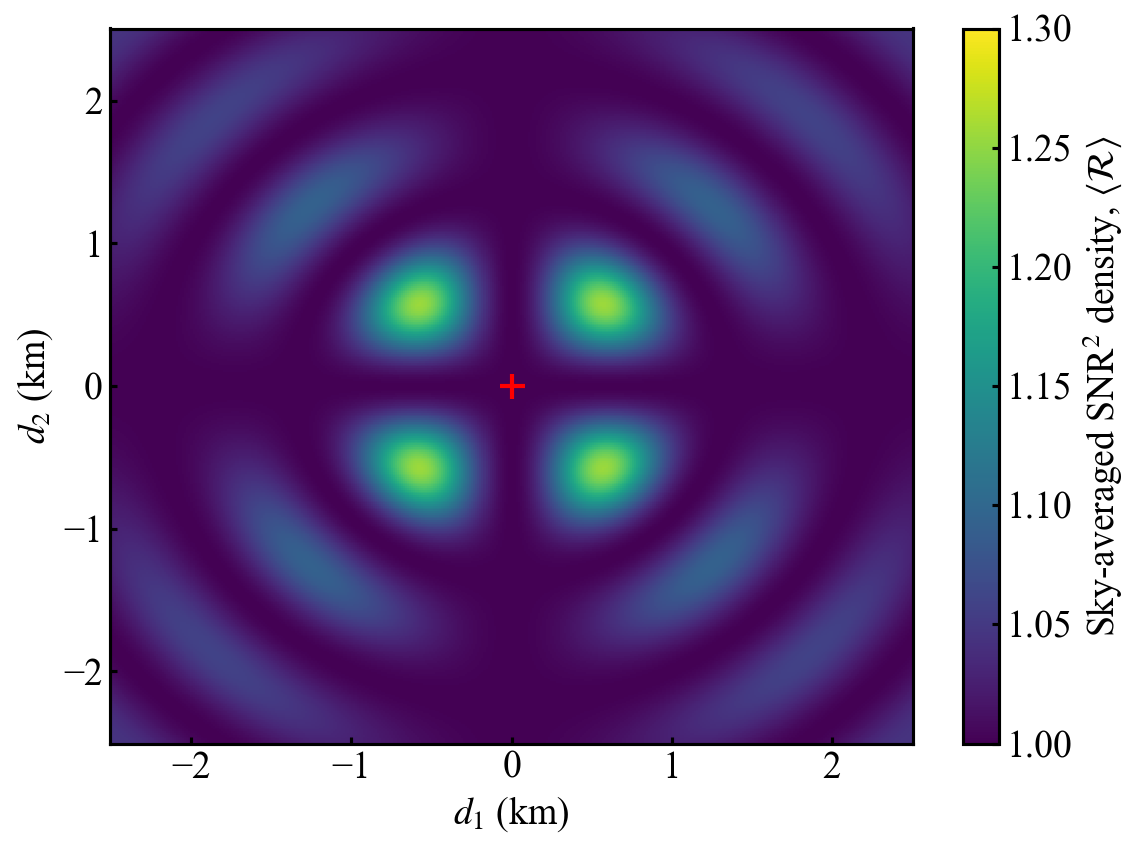

In [12]:
plot_results(param1, param2, res_grid)